# PyTorch ResNet Training for Affect Recognition Dataset
This notebook trains ResNet models for multi-task learning: expression classification and valence-arousal regression

In [55]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple
import random

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torchvision.transforms as T

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

PyTorch version: 2.6.0+cu124
CUDA available: True
GPU: Tesla T4
Using device: cuda


In [46]:
class Config:
    # Dataset paths - MODIFY THESE PATHS ACCORDING TO YOUR SETUP
    DATASET_ROOT = "/kaggle/input/arousal-valence-dataset/Dataset/Dataset"  # Change this to your dataset path
    IMAGES_DIR = os.path.join(DATASET_ROOT, "images")
    ANNOTATIONS_DIR = os.path.join(DATASET_ROOT, "annotations")
    
    # Model parameters
    IMAGE_SIZE = 224
    BATCH_SIZE = 32
    EPOCHS = 100
    LEARNING_RATE = 1e-3
    WEIGHT_DECAY = 1e-4
    
    # Split ratios
    SPLIT_RATIOS = {"train": 0.8, "val": 0.1, "test": 0.1}
    
    # Expression labels
    EXPRESSION_LABELS = {
        0: "Neutral", 1: "Happy", 2: "Sad", 3: "Surprise", 
        4: "Fear", 5: "Disgust", 6: "Anger", 7: "Contempt"
    }
    
    NUM_CLASSES = 8

config = Config()

In [47]:
@dataclass
class SampleIndex:
    sample_id: str
    image_path: str
    exp_path: str
    val_path: str
    aro_path: str

def _id_to_paths(sample_id: str) -> SampleIndex:
    """Build file paths for a given sample id."""
    img_path = os.path.join(config.IMAGES_DIR, f"{sample_id}.jpg")
    exp_path = os.path.join(config.ANNOTATIONS_DIR, f"{sample_id}_exp.npy")
    val_path = os.path.join(config.ANNOTATIONS_DIR, f"{sample_id}_val.npy")
    aro_path = os.path.join(config.ANNOTATIONS_DIR, f"{sample_id}_aro.npy")
    return SampleIndex(sample_id, img_path, exp_path, val_path, aro_path)

def build_index() -> List[SampleIndex]:
    """Scan dataset folders and build a valid sample index."""
    ids = []
    for name in os.listdir(config.IMAGES_DIR):
        if not name.lower().endswith(".jpg"):
            continue
        sample_id = os.path.splitext(name)[0]
        idx = _id_to_paths(sample_id)
        if (os.path.exists(idx.exp_path) and 
            os.path.exists(idx.val_path) and 
            os.path.exists(idx.aro_path)):
            ids.append(sample_id)
    
    ids.sort(key=lambda x: int(x) if x.isdigit() else x)
    return [_id_to_paths(i) for i in ids]

def stratified_split(indices: List[SampleIndex], labels: List[int], 
                    ratios: Dict[str, float] = None, seed: int = SEED):
    """Create a stratified train/val/test split."""
    if ratios is None:
        ratios = config.SPLIT_RATIOS
    
    rng = np.random.RandomState(seed)
    per_class = defaultdict(list)
    for i, y in enumerate(labels):
        per_class[int(y)].append(i)
    
    train_idx, val_idx, test_idx = [], [], []
    
    for y, idxs in per_class.items():
        idxs = np.array(idxs)
        rng.shuffle(idxs)
        n = len(idxs)
        n_train = int(round(n * ratios["train"]))
        n_val = int(round(n * ratios["val"]))
        
        train_idx.extend(idxs[:n_train].tolist())
        val_idx.extend(idxs[n_train:n_train + n_val].tolist())
        test_idx.extend(idxs[n_train + n_val:].tolist())
    
    return train_idx, val_idx, test_idx

In [48]:
class AffectDataset(Dataset):
    def __init__(self, indices: List[SampleIndex], transform=None):
        self.indices = indices
        self.transform = transform

    def __len__(self) -> int:
        return len(self.indices)

    def __getitem__(self, idx: int):
        entry = self.indices[idx]

        # Load image
        img = Image.open(entry.image_path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)

      
        # Load annotations
        exp = np.load(entry.exp_path).astype(np.int64)
        if exp.ndim:
            exp = int(exp.reshape(-1)[0])
        else:
            exp = int(exp)  # ← NEW: Ensure it's an integer
        val = float(np.load(entry.val_path).reshape(-1)[0])
        aro = float(np.load(entry.aro_path).reshape(-1)[0])

        exp = torch.tensor(exp, dtype=torch.long)
        target_reg = torch.tensor([val, aro], dtype=torch.float32)

        return {
            "image": img,
            "exp": exp,
            "reg": target_reg,
            "id": entry.sample_id,
        }

In [49]:
def get_train_transforms():
    """Data augmentation for training."""
    return transforms.Compose([
        transforms.Resize((config.IMAGE_SIZE, config.IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.RandomRotation(degrees=10),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

def get_eval_transforms():
    """Data preprocessing for evaluation."""
    return transforms.Compose([
        transforms.Resize((config.IMAGE_SIZE, config.IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

In [50]:
class DualHead(nn.Module):
    def __init__(self, in_features: int, num_classes: int = config.NUM_CLASSES):
        super().__init__()
        self.cls = nn.Linear(in_features, num_classes)
        self.reg = nn.Linear(in_features, 2)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """
        This function runs classification and regression heads.
        """
        logits = self.cls(x)
        reg = torch.tanh(self.reg(x))
        return logits, reg

class SEBlock(nn.Module):
    """Squeeze-and-Excitation Block for channel attention."""
    def __init__(self, channels: int, reduction: int = 16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class EnhancedDualHead(nn.Module):
    def __init__(self, in_features: int, num_classes: int = config.NUM_CLASSES):
        super().__init__()
        hidden_dim = 1024
        
        self.shared = nn.Sequential(
            nn.Linear(in_features, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3)
        )
        
        self.cls = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim // 2, num_classes)
        )
        
        self.reg = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim // 2, 2)
        )
    
    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        shared_features = self.shared(x)
        logits = self.cls(shared_features)
        reg = torch.tanh(self.reg(shared_features))
        return logits, reg

class SEResNet50(nn.Module):
    """ResNet-50 with Squeeze-and-Excitation blocks."""
    def __init__(self, pretrained: bool = True):
        super().__init__()
        # Load pretrained ResNet-50
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None)
        
        # Extract individual components
        self.conv1 = resnet.conv1
        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool
        
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4
        
        # Add SE blocks after layer2, layer3, and layer4
        self.se_block2 = SEBlock(512)   # After layer2 (512 channels)
        self.se_block3 = SEBlock(1024)  # After layer3 (1024 channels)
        self.se_block4 = SEBlock(2048)  # After layer4 (2048 channels)
        
        # Add pooling and enhanced heads
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.head = EnhancedDualHead(resnet.fc.in_features)
    
    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        # Forward through backbone layers
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.se_block2(x)
        
        x = self.layer3(x)
        x = self.se_block3(x)
        
        x = self.layer4(x)
        x = self.se_block4(x)
        
        # Global pooling and classification
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.head(x)

def build_model(name: str = "se_resnet50", pretrained: bool = True) -> nn.Module:
    """Build a model by name."""
    name = name.lower()
    if name == "resnet50":
        m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None)
        feature_dim = m.fc.in_features
        backbone = nn.Sequential(*list(m.children())[:-2])
        return nn.Sequential(
            backbone,
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(1),
            DualHead(feature_dim),
        )
    elif name == "se_resnet50":
        return SEResNet50(pretrained=pretrained)
    else:
        raise ValueError(f"Unknown model: {name}")

In [51]:
class MultiTaskLoss(nn.Module):
    def __init__(self, cls_weight=1.0, reg_weight=0.5, class_weights=None):
        super().__init__()
        self.cls_weight = cls_weight
        self.reg_weight = reg_weight
        
        # Classification loss with class weights
        if class_weights is not None:
            class_weights = torch.FloatTensor(class_weights).to(device)
        self.cls_criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
        self.reg_criterion = nn.MSELoss()
    
    def forward(self, cls_pred, reg_pred, cls_target, reg_target):
        cls_loss = self.cls_criterion(cls_pred, cls_target)
        reg_loss = self.reg_criterion(reg_pred, reg_target)
        
        total_loss = self.cls_weight * cls_loss + self.reg_weight * reg_loss
        
        return {
            'total_loss': total_loss,
            'cls_loss': cls_loss,
            'reg_loss': reg_loss
        }

In [52]:
class AverageMeter:
    def __init__(self):
        self.reset()
    
    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0
    
    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

def accuracy(output, target):
    """Calculate classification accuracy."""
    pred = output.argmax(dim=1)
    correct = pred.eq(target).float()
    return correct.mean().item()

def train_epoch(model, dataloader, criterion, optimizer, epoch):
    model.train()
    
    losses = AverageMeter()
    cls_losses = AverageMeter()
    reg_losses = AverageMeter()
    accuracies = AverageMeter()
    
    for i, batch in enumerate(dataloader):
        images = batch['image'].to(device)
        exp_targets = batch['exp'].to(device)
        reg_targets = batch['reg'].to(device)
        
        # Forward pass
        cls_pred, reg_pred = model(images)
        
        # Calculate losses
        loss_dict = criterion(cls_pred, reg_pred, exp_targets, reg_targets)
        
        # Backward pass
        optimizer.zero_grad()
        loss_dict['total_loss'].backward()
        optimizer.step()
        
        # Update metrics
        batch_size = images.size(0)
        losses.update(loss_dict['total_loss'].item(), batch_size)
        cls_losses.update(loss_dict['cls_loss'].item(), batch_size)
        reg_losses.update(loss_dict['reg_loss'].item(), batch_size)
        accuracies.update(accuracy(cls_pred, exp_targets), batch_size)
        
        if i % 50 == 0:
            print(f'Epoch [{epoch}][{i}/{len(dataloader)}] '
                  f'Loss: {losses.val:.4f} ({losses.avg:.4f}) '
                  f'Acc: {accuracies.val:.4f} ({accuracies.avg:.4f})')
    
    return {
        'loss': losses.avg,
        'cls_loss': cls_losses.avg,
        'reg_loss': reg_losses.avg,
        'accuracy': accuracies.avg
    }

def validate_epoch(model, dataloader, criterion):
    model.eval()
    
    losses = AverageMeter()
    cls_losses = AverageMeter()
    reg_losses = AverageMeter()
    accuracies = AverageMeter()
    
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for batch in dataloader:
            images = batch['image'].to(device)
            exp_targets = batch['exp'].to(device)
            reg_targets = batch['reg'].to(device)
            
            # Forward pass
            cls_pred, reg_pred = model(images)
            
            # Calculate losses
            loss_dict = criterion(cls_pred, reg_pred, exp_targets, reg_targets)
            
            # Update metrics
            batch_size = images.size(0)
            losses.update(loss_dict['total_loss'].item(), batch_size)
            cls_losses.update(loss_dict['cls_loss'].item(), batch_size)
            reg_losses.update(loss_dict['reg_loss'].item(), batch_size)
            accuracies.update(accuracy(cls_pred, exp_targets), batch_size)
            
            # Store predictions for detailed analysis
            all_preds.extend(cls_pred.argmax(dim=1).cpu().numpy())
            all_targets.extend(exp_targets.cpu().numpy())
    
    return {
        'loss': losses.avg,
        'cls_loss': cls_losses.avg,
        'reg_loss': reg_losses.avg,
        'accuracy': accuracies.avg,
        'predictions': all_preds,
        'targets': all_targets
    }

In [56]:
print("Building dataset index...")
try:
    all_indices = build_index()
    print(f"Found {len(all_indices)} valid samples")
    
    if len(all_indices) == 0:
        print("ERROR: No valid samples found!")
        print("Please check your dataset paths in the Config class")
        raise Exception("No valid samples found - check your dataset paths!")

except Exception as e:
    print(f"Error building index: {e}")
    raise

# Load all labels for stratified splitting
print("Loading labels for stratification...")
all_labels = []
for idx in all_indices:
    exp = np.load(idx.exp_path).astype(np.int64)
    if exp.ndim:
        exp = int(exp.reshape(-1)[0])
    else:
        exp = int(exp)
    all_labels.append(exp)

print(f"Loaded {len(all_labels)} labels")
print(f"Label range: {min(all_labels)} to {max(all_labels)}")
print(f"Unique labels: {sorted(set(all_labels))}")

# Check for label distribution
label_counts = np.bincount(all_labels, minlength=config.NUM_CLASSES)
print(f"Label distribution: {label_counts}")
print(f"Class names: {[config.EXPRESSION_LABELS[i] for i in range(config.NUM_CLASSES)]}")

# CRITICAL: Check for class imbalance
print(f"\n🚨 CLASS IMBALANCE CHECK:")
total_samples = len(all_labels)
for i, count in enumerate(label_counts):
    percentage = (count / total_samples) * 100
    print(f"  {config.EXPRESSION_LABELS[i]}: {count} samples ({percentage:.1f}%)")

# Calculate class weights for handling imbalance
classes = np.arange(config.NUM_CLASSES)
class_weights_array = compute_class_weight('balanced', classes=classes, y=all_labels)
class_weights_dict = {i: weight for i, weight in enumerate(class_weights_array)}
print(f"\n📊 Calculated class weights: {class_weights_dict}")

# Perform stratified split
train_idx, temp_idx, train_labels_split, temp_labels = train_test_split(
    range(len(all_indices)), all_labels, 
    test_size=0.2, stratify=all_labels, random_state=SEED
)

# Second split: val vs test
val_idx, test_idx, _, _ = train_test_split(
    temp_idx, temp_labels,
    test_size=0.5, stratify=temp_labels, random_state=SEED
)

print(f"\nTrain samples: {len(train_idx)}")
print(f"Validation samples: {len(val_idx)}")
print(f"Test samples: {len(test_idx)}")

# Create datasets and dataloaders
train_indices = [all_indices[i] for i in train_idx]
val_indices = [all_indices[i] for i in val_idx]
test_indices = [all_indices[i] for i in test_idx]

train_dataset = AffectDataset(train_indices, transform=get_train_transforms())
val_dataset = AffectDataset(val_indices, transform=get_eval_transforms())
test_dataset = AffectDataset(test_indices, transform=get_eval_transforms())

train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=4)

print("Datasets and dataloaders created successfully!")

Building dataset index...
Found 3999 valid samples
Loading labels for stratification...
Loaded 3999 labels
Label range: 0 to 7
Unique labels: [0, 1, 2, 3, 4, 5, 6, 7]
Label distribution: [500 500 500 500 500 500 500 499]
Class names: ['Neutral', 'Happy', 'Sad', 'Surprise', 'Fear', 'Disgust', 'Anger', 'Contempt']

🚨 CLASS IMBALANCE CHECK:
  Neutral: 500 samples (12.5%)
  Happy: 500 samples (12.5%)
  Sad: 500 samples (12.5%)
  Surprise: 500 samples (12.5%)
  Fear: 500 samples (12.5%)
  Disgust: 500 samples (12.5%)
  Anger: 500 samples (12.5%)
  Contempt: 499 samples (12.5%)

📊 Calculated class weights: {0: 0.99975, 1: 0.99975, 2: 0.99975, 3: 0.99975, 4: 0.99975, 5: 0.99975, 6: 0.99975, 7: 1.001753507014028}

Train samples: 3199
Validation samples: 400
Test samples: 400
Datasets and dataloaders created successfully!


In [58]:
# Verify the splits are balanced
train_labels_check = [all_labels[i] for i in train_idx]
val_labels_check = [all_labels[i] for i in val_idx]
test_labels_check = [all_labels[i] for i in test_idx]

print("Verification - actual class counts:")
print(f"Train: {np.bincount(train_labels_check, minlength=8)}")
print(f"Val: {np.bincount(val_labels_check, minlength=8)}")
print(f"Test: {np.bincount(test_labels_check, minlength=8)}")

Verification - actual class counts:
Train: [400 400 400 400 400 400 400 399]
Val: [50 50 50 50 50 50 50 50]
Test: [50 50 50 50 50 50 50 50]


In [59]:
# Build model
print("Building SE-ResNet50 model...")
model = build_model("se_resnet50", pretrained=True)
model = model.to(device)

# Print model summary
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model has {count_parameters(model):,} trainable parameters")

# Setup loss function with class weights
criterion = MultiTaskLoss(
    cls_weight=2.0,  # Higher weight for classification
    reg_weight=0.5,  # Lower weight for regression
    class_weights=class_weights_array
)

# Setup optimizer
optimizer = optim.AdamW(
    model.parameters(),
    lr=config.LEARNING_RATE,
    weight_decay=config.WEIGHT_DECAY
)

# Setup scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min',
    factor=0.5,
    patience=10,
    verbose=True
)

Building SE-ResNet50 model...


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:01<00:00, 85.2MB/s]


Model has 27,353,162 trainable parameters


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [60]:
print("Starting training...")

train_history = {
    'train_loss': [],
    'train_accuracy': [],
    'val_loss': [],
    'val_accuracy': []
}

best_val_acc = 0.0
patience_counter = 0
patience = 20

for epoch in range(config.EPOCHS):
    print(f'\nEpoch {epoch + 1}/{config.EPOCHS}')
    print('-' * 60)
    
    # Training phase
    train_metrics = train_epoch(model, train_loader, criterion, optimizer, epoch + 1)
    
    # Validation phase
    val_metrics = validate_epoch(model, val_loader, criterion)
    
    # Update scheduler
    scheduler.step(val_metrics['loss'])
    
    # Update history
    train_history['train_loss'].append(train_metrics['loss'])
    train_history['train_accuracy'].append(train_metrics['accuracy'])
    train_history['val_loss'].append(val_metrics['loss'])
    train_history['val_accuracy'].append(val_metrics['accuracy'])
    
    print(f'Train Loss: {train_metrics["loss"]:.4f}, Train Acc: {train_metrics["accuracy"]:.4f}')
    print(f'Val Loss: {val_metrics["loss"]:.4f}, Val Acc: {val_metrics["accuracy"]:.4f}')
    
    # Save best model
    if val_metrics['accuracy'] > best_val_acc:
        best_val_acc = val_metrics['accuracy']
        torch.save(model.state_dict(), 'best_se_resnet50_affect.pth')
        print(f'New best validation accuracy: {best_val_acc:.4f}')
        patience_counter = 0
    else:
        patience_counter += 1
    
    # Early stopping
    if patience_counter >= patience:
        print(f'Early stopping triggered after {epoch + 1} epochs')
        break

print("Training completed!")

Starting training...

Epoch 1/100
------------------------------------------------------------
Epoch [1][0/100] Loss: 4.4628 (4.4628) Acc: 0.0938 (0.0938)
Epoch [1][50/100] Loss: 4.3796 (4.3975) Acc: 0.1562 (0.1771)
Train Loss: 4.2330, Train Acc: 0.2004
Val Loss: 4.0152, Val Acc: 0.2325
New best validation accuracy: 0.2325

Epoch 2/100
------------------------------------------------------------
Epoch [2][0/100] Loss: 4.0399 (4.0399) Acc: 0.1875 (0.1875)
Epoch [2][50/100] Loss: 3.7659 (3.9361) Acc: 0.2500 (0.2770)
Train Loss: 3.8948, Train Acc: 0.2879
Val Loss: 3.8924, Val Acc: 0.2875
New best validation accuracy: 0.2875

Epoch 3/100
------------------------------------------------------------
Epoch [3][0/100] Loss: 3.3932 (3.3932) Acc: 0.3438 (0.3438)
Epoch [3][50/100] Loss: 3.4755 (3.6708) Acc: 0.3438 (0.3199)
Train Loss: 3.6834, Train Acc: 0.3260
Val Loss: 3.7982, Val Acc: 0.3100
New best validation accuracy: 0.3100

Epoch 4/100
------------------------------------------------------

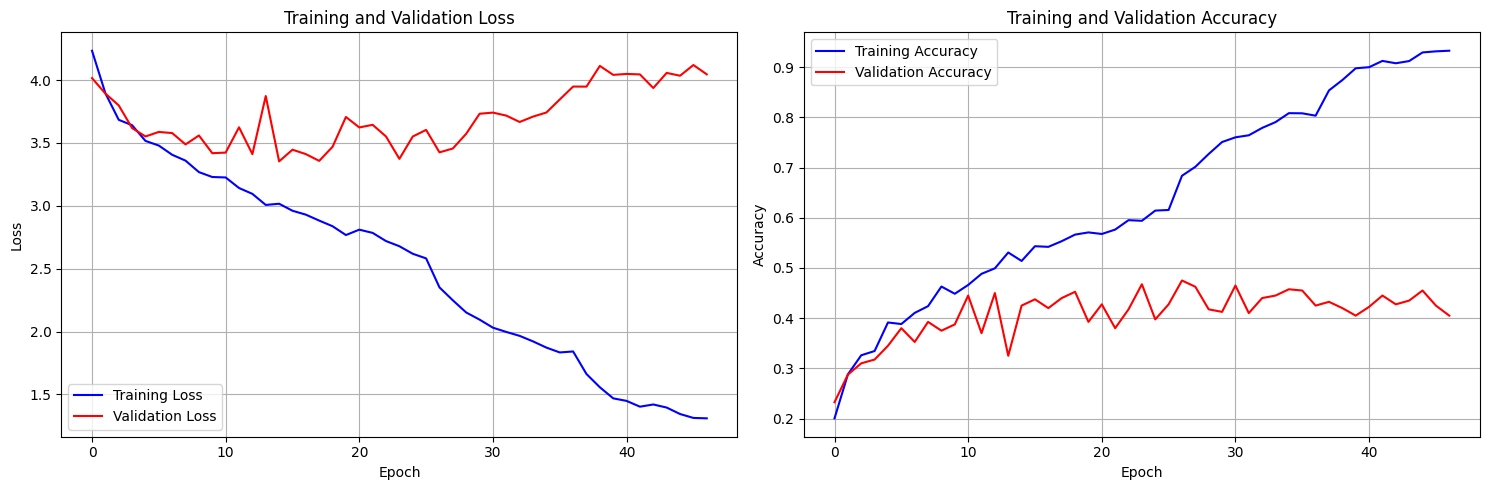

In [61]:
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Loss plot
    ax1.plot(history['train_loss'], label='Training Loss', color='blue')
    ax1.plot(history['val_loss'], label='Validation Loss', color='red')
    ax1.set_title('Training and Validation Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)
    
    # Accuracy plot
    ax2.plot(history['train_accuracy'], label='Training Accuracy', color='blue')
    ax2.plot(history['val_accuracy'], label='Validation Accuracy', color='red')
    ax2.set_title('Training and Validation Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_training_history(train_history)

Loading best model for evaluation...
Evaluating on test set...

Test Results:
Test Loss: 3.1736
Test Accuracy: 0.4850

Classification Report:
              precision    recall  f1-score   support

     Neutral       0.35      0.36      0.36        50
       Happy       0.60      0.58      0.59        50
         Sad       0.53      0.48      0.51        50
    Surprise       0.41      0.54      0.47        50
        Fear       0.51      0.56      0.53        50
     Disgust       0.53      0.60      0.56        50
       Anger       0.45      0.40      0.43        50
    Contempt       0.53      0.36      0.43        50

    accuracy                           0.48       400
   macro avg       0.49      0.48      0.48       400
weighted avg       0.49      0.48      0.48       400



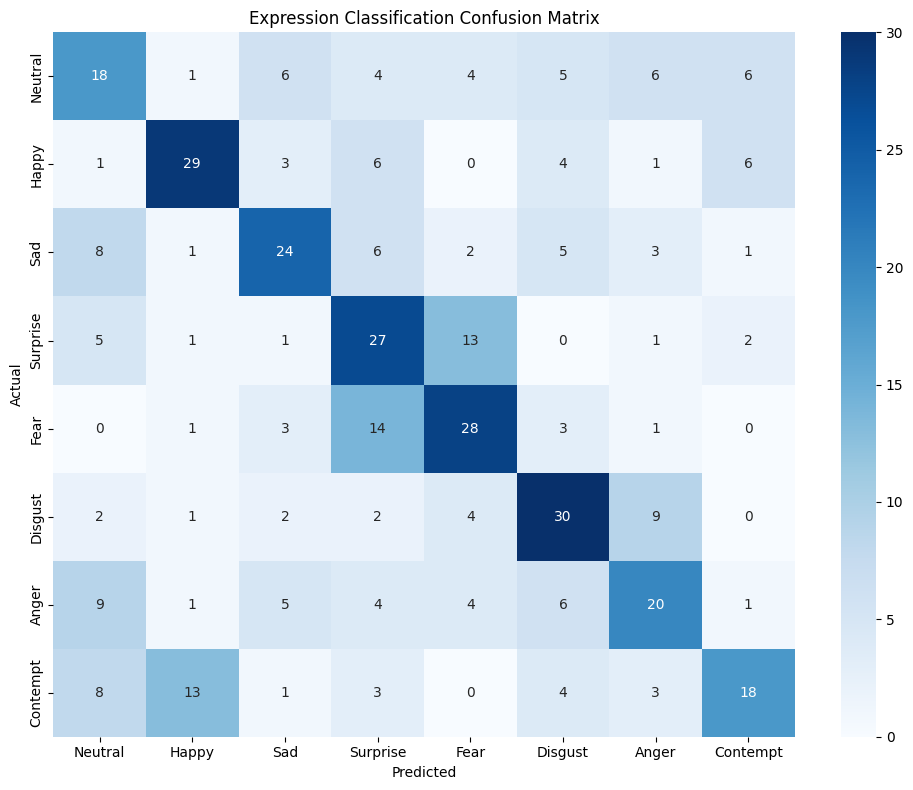

In [62]:
print("Loading best model for evaluation...")
model.load_state_dict(torch.load('best_se_resnet50_affect.pth'))

print("Evaluating on test set...")
test_metrics = validate_epoch(model, test_loader, criterion)

print(f"\nTest Results:")
print(f"Test Loss: {test_metrics['loss']:.4f}")
print(f"Test Accuracy: {test_metrics['accuracy']:.4f}")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(
    test_metrics['targets'],
    test_metrics['predictions'],
    target_names=[config.EXPRESSION_LABELS[i] for i in range(config.NUM_CLASSES)]
))

# Confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(test_metrics['targets'], test_metrics['predictions'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[config.EXPRESSION_LABELS[i] for i in range(config.NUM_CLASSES)],
            yticklabels=[config.EXPRESSION_LABELS[i] for i in range(config.NUM_CLASSES)])
plt.title('Expression Classification Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [64]:
# Save the final model
torch.save(model.state_dict(), 'final_se_resnet50_affect.pth')
print("Model saved")

Model saved
